#**RAG with llama-index**
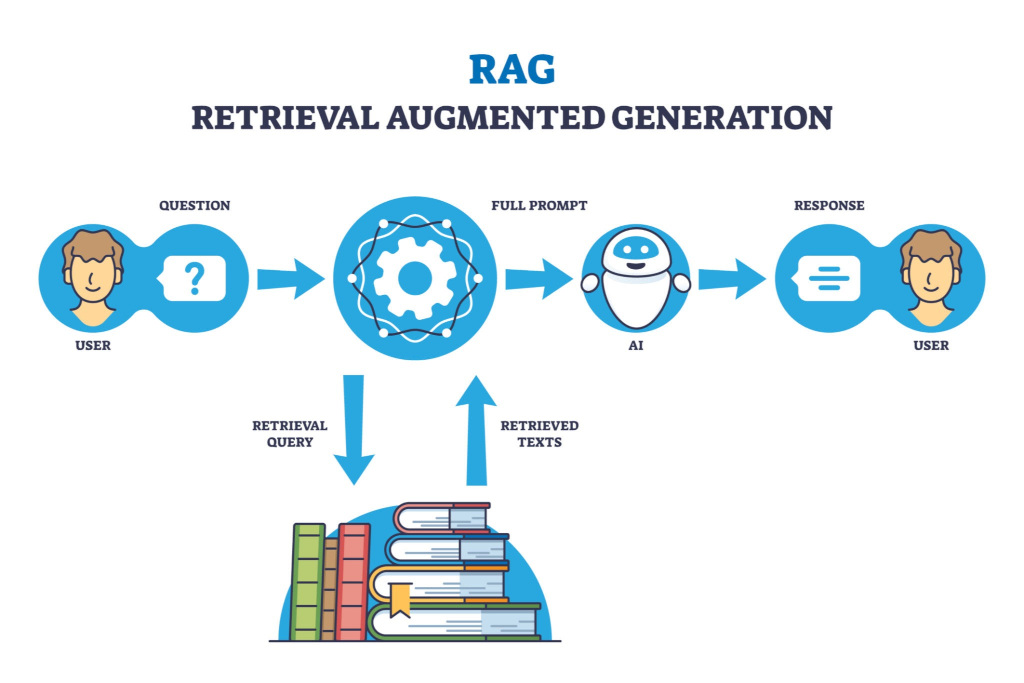

In [ ]:
!pip install llama-index pypdf

#**LlamaIndex is about Retrieval + Generation**

*   How it works (Step 1 - Retrieval): It can use keyword search, but its main power comes from semantic search (vector search). It maps concepts and meaning, not just words.
*   What it understands: It does understand meaning. A search for "king" will find documents that talk about "monarchs," "royalty," or "sovereigns" because their vector embeddings are mathematically close in "concept space."
*   How it works (Step 2 - Generation): This is the key. LlamaIndex doesn't just give you the list of documents. It takes the most relevant chunks of text (the "context") and augments a prompt to an LLM (like GPT-4). It says, "Using only this context I found, answer the user's question."
*   What it gives you: A direct, synthesized answer in natural language.


In [ ]:
import os
import sys
from llama_index.core import (
    VectorStoreIndex,
    SimpleDirectoryReader,
    StorageContext,
    load_index_from_storage,
    Settings
)
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

# Define the directories for data, storage, and the log file
DATA_DIR = "./data"
STORAGE_DIR = "./storage"
INDEXED_FILES_LOG = os.path.join(STORAGE_DIR, "indexed_files.log")

# Replace "YOUR_API_KEY_HERE" with your actual OpenAI API key.
# For better security, prefer setting this as an environment variable.
# os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY_HERE"

if "OPENAI_API_KEY" not in os.environ:
    print(
        "OPENAI_API_KEY environment variable not set. "
        "Please set the variable or add it directly to the script."
    )
    sys.exit(1)

print("Configuring LlamaIndex settings...")
Settings.llm = OpenAI(model="gpt-4o-mini")
Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small")

def load_indexed_files_log():
    """Loads the set of filenames that have already been indexed."""
    if os.path.exists(INDEXED_FILES_LOG):
        with open(INDEXED_FILES_LOG, "r") as f:
            # Read lines and strip whitespace/newlines
            return set(line.strip() for line in f if line.strip())
    return set()

def save_indexed_files_log(indexed_files_set):
    """Saves the updated set of indexed filenames to the log."""
    with open(INDEXED_FILES_LOG, "w") as f:
        for filename in indexed_files_set:
            f.write(filename + "\n")

def load_or_create_index():
    """
    Loads an existing index from the STORAGE_DIR or
    creates a new, empty index if one doesn't exist.
    """
    if not os.path.exists(DATA_DIR):
        print(f"Creating data directory at: {DATA_DIR}")
        os.makedirs(DATA_DIR)

    if not os.path.exists(STORAGE_DIR):
        print(f"Creating storage directory at: {STORAGE_DIR}")
        os.makedirs(STORAGE_DIR)

    if os.path.exists(os.path.join(STORAGE_DIR, "docstore.json")):
        print(f"Loading existing index from {STORAGE_DIR}...")
        try:
            storage_context = StorageContext.from_defaults(persist_dir=STORAGE_DIR)
            index = load_index_from_storage(storage_context)
            print("Index loaded successfully.")
        except Exception as e:
            print(f"Error loading index: {e}")
            print("Creating a new index instead.")
            # Create an empty index if loading fails
            index = VectorStoreIndex.from_documents([], storage_context=StorageContext.from_defaults())
    else:
        print("No existing index found. Creating a new, empty index.")
        # Create an empty storage context and an empty index
        storage_context = StorageContext.from_defaults()
        index = VectorStoreIndex.from_documents([], storage_context=storage_context)
        # Persist the empty index structure
        index.storage_context.persist(persist_dir=STORAGE_DIR)
        print(f"New index created and saved in {STORAGE_DIR}.")

    return index

def update_index(index, indexed_files_log):
    """
    Checks the DATA_DIR for any new files not in the log,
    loads them, and inserts them into the index.
    """
    print("Checking for new documents in ./data...")

    try:
        all_files_in_data = set(
            f for f in os.listdir(DATA_DIR)
            if os.path.isfile(os.path.join(DATA_DIR, f))
        )
    except FileNotFoundError:
        print(f"Error: Data directory '{DATA_DIR}' not found.")
        return False # Return a flag indicating update failed

    # Find the set difference
    new_files = all_files_in_data - indexed_files_log

    if not new_files:
        print("No new documents found. Index is up-to-date.")
        return False # Return a flag indicating no update was needed

    print(f"Found {len(new_files)} new document(s): {', '.join(new_files)}")

    # Create a list of full file paths for the reader
    new_file_paths = [os.path.join(DATA_DIR, f) for f in new_files]

    try:
        # Load *only* the new documents
        new_documents = SimpleDirectoryReader(input_files=new_file_paths).load_data()

        if not new_documents:
            print("Could not load any data from the new files.")
            return False

        print(f"Indexing {len(new_documents)} new document chunks...")
        # Insert the new documents into the existing index
        for doc in new_documents:
            index.insert_document(doc)

        # Update our log
        indexed_files_log.update(new_files)

        print("Persisting index changes to disk...")
        # CRITICAL: Save the updated index
        index.storage_context.persist(persist_dir=STORAGE_DIR)

        # CRITICAL: Save the updated log
        save_indexed_files_log(indexed_files_log)

        print("Successfully indexed and saved new documents.")
        return True # Return a flag indicating the index was updated

    except Exception as e:
        print(f"An error occurred during indexing: {e}")
        # Remove the files from the log if indexing failed
        # so we can retry next time
        indexed_files_log.difference_update(new_files)
        return False


In [ ]:
"""
Sample script to load the index, check for updates,
and start the query loop.
"""
print("--- Incremental PDF Query Engine ---")

index = load_or_create_index()
indexed_files_log = load_indexed_files_log()

# Run an initial update check on startup
if update_index(index, indexed_files_log):
    print("Query engine will be built with the latest updates.")

print("Creating query engine...")
query_engine = index.as_query_engine()
print("Query engine created. You can now ask questions.")

print("\n--- Start Chatting With Your Documents ---")
print("Type 'update' to check for new files.")
print("Type 'exit' or 'quit' to stop.")

while True:
    try:
        user_input = input("\nYour question: ")

        if user_input.lower() in ["exit", "quit"]:
            break

        if user_input.lower() == "update":
            # This is the "callable method" to add new files
            print("\n--- Running Manual Update ---")
            was_updated = update_index(index, indexed_files_log)
            if was_updated:
                print("Re-creating query engine to include new data...")
                # Re-create the query engine to use the updated index
                query_engine = index.as_query_engine()
                print("Query engine is now up-to-date.")
            print("--- Update Check Complete ---")
            continue

        if not user_input.strip():
            continue

        print("Querying...")
        response = query_engine.query(user_input)

        print("\nAnswer:")
        print(str(response))

    except KeyboardInterrupt:
        break
    except Exception as e:
        print(f"An error occurred: {e}")
